## Chargement des packages 


In [3]:
library(tidyverse)    
library(ggplot2)      
library(corrplot)     
library(FactoMineR)   
library(factoextra)   
library(vcd)          
library(GGally)       
library(moments)      
library(gridExtra)    
library(reshape2)

# Analyse exploratoire des données 

## 1. Chargement et vérification des données 

In [4]:
df <- read.csv("healthcare_synthetic_data.csv", stringsAsFactors = FALSE)


#### 1.1 Dimensions et aperçu général 

In [5]:
head(df)
cat("Dimensions du dataset: ",dim(df))
anyDuplicated(df$ID_patient)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


Dimensions du dataset:  15000 19

[1] 0

Le jeu de données contient bien **15 000 patients** (nombre de ligne) et **19 variables** (nombre de colonne).  
La variable `Patient_ID` est un identifiant unique : elle sera **supprimée** pour l'analyse. On vérifie que la colonne Patient_ID est a valeur unique avec la commande
**anyDuplicated** retournant 0 si il n'y a pas de doublons.
Les variables qualitatives sont déjà encodées sous forme d'entiers, il faudra les convertir en **facteurs** pour que R les traite correctement.

In [6]:
str(df)
cat("\nValeurs manquantes par variable :\n")
print(colSums(is.na(df)))
df <- df %>% select(-Patient_ID)

'data.frame':	15000 obs. of  19 variables:
 $ Patient_ID             : chr  "PID-00001" "PID-00002" "PID-00003" "PID-00004" ...
 $ Age                    : int  60 53 62 73 52 52 73 64 49 61 ...
 $ Gender                 : int  0 0 1 1 1 0 0 0 0 1 ...
 $ Height_cm              : num  147 162 175 173 179 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 79.8 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 25 23.7 25 34.5 28.2 36.3 ...
 $ Systolic_BP            : int  140 128 141 136 122 134 149 129 139 131 ...
 $ Diastolic_BP           : int  89 81 100 96 80 92 98 90 91 91 ...
 $ Cholesterol_Total      : int  217 203 173 193 236 225 260 237 227 206 ...
 $ Cholesterol_LDL        : int  151 119 124 117 153 155 166 160 138 139 ...
 $ Cholesterol_HDL        : int  52 38 45 45 41 48 46 44 37 38 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 79 103 103 108 90 103 ...
 $ Smoking_Status         : int  0 0 0 0 0 0 0 0 1 0 ...
 $ Alcohol_Consumption    : int  1 0 0 0 1 0 0 1 0 

Aucune valeur manquante n'est détectée dans le jeu de données.  
La variable `Patient_ID` a été supprimée car elle n'apporte aucune information prédictive.

Les variables qualitatives suivantes sont encodées en entiers et doivent être converties en facteurs :

| Variable                   | Encodage                                          |
| -------------------------- | ------------------------------------------------- |
| `Genre`                    | 0 = Femme, 1 = Homme                              |
| `Statut_Tabac`             | 0 = Non-fumeur, 1 = Fumeur                        |
| `Consommation_Alcool`      | 0 = Aucune, 1 = Modérée, 2 = Élevée               |
| `Niveau_Activité_Physique` | 0 = Aucun, 1 = Faible, 2 = Modéré, 3 = Élevé |
| `Antécédents_Familiaux`    | 0 = Non, 1 = Oui                                  |
| `Risque_Maladie_Cardiaque` | 0 = Risque faible, 1 = Risque élevé               |


#### 1.2 Conversion des variables qualitatives

In [7]:
df[,"Smoking_Status"]<- as.factor(df[,"Smoking_Status"])
df[,"Gender"]<- as.factor(df[,"Gender"])
df[,"Family_History"]<- as.factor(df[,"Family_History"])
df[,"Heart_Disease_Risk"]<- as.factor(df[,"Heart_Disease_Risk"])
df[,"Alcohol_Consumption"]<- as.factor(df[,"Alcohol_Consumption"])
df[,"Physical_Activity_Level"]<- as.factor(df[,"Physical_Activity_Level"])

#### 1.3 Statistique descriptive 

In [8]:
summary(df)

      Age        Gender     Height_cm       Weight_kg           BMI       
 Min.   :25.00   0:7622   Min.   :138.5   Min.   : 33.70   Min.   :14.50  
 1st Qu.:46.00   1:7378   1st Qu.:158.5   1st Qu.: 65.20   1st Qu.:24.50  
 Median :55.00            Median :164.7   Median : 73.90   Median :27.20  
 Mean   :54.54            Mean   :165.3   Mean   : 75.25   Mean   :27.45  
 3rd Qu.:63.00            3rd Qu.:172.0   3rd Qu.: 83.90   3rd Qu.:30.00  
 Max.   :85.00            Max.   :198.1   Max.   :150.10   Max.   :46.10  
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0     3rd Qu.:152.0  
 Max.   :182.0   Max.   :120.00   Max.   :303.0     Max.   :210.0  

##### 1.3.1 Statistque unidimensionnelle

Warning message:
"The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead."
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


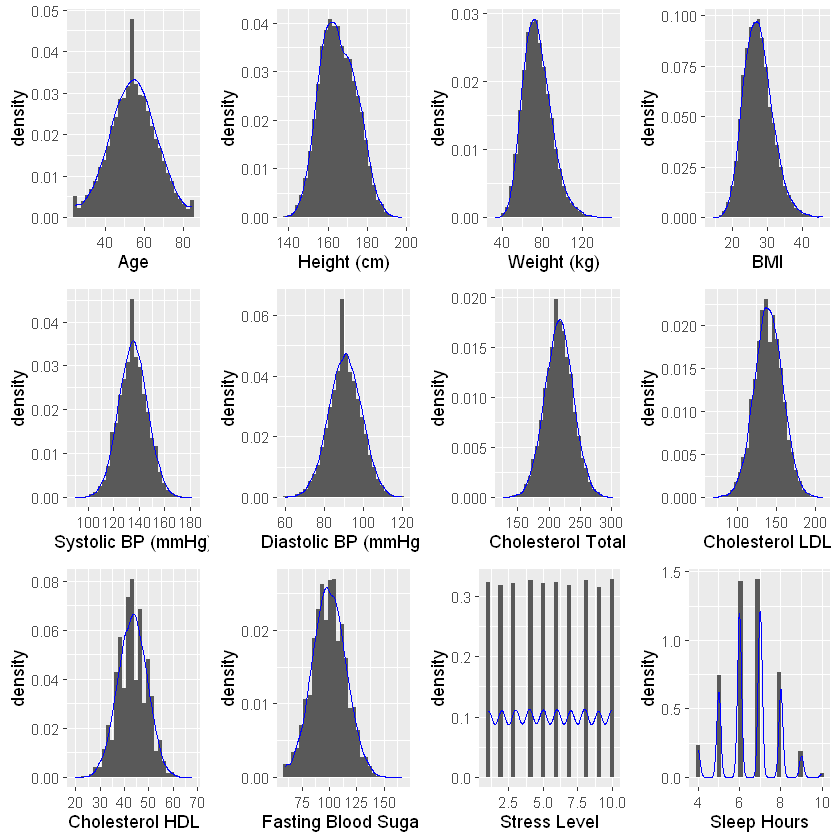

In [9]:
g1  <- ggplot(df, aes(x=df[,"Age"]))               + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Age")              
g2  <- ggplot(df, aes(x=df[,"Height_cm"]))         + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Height (cm)")      
g3  <- ggplot(df, aes(x=df[,"Weight_kg"]))         + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Weight (kg)")      
g4  <- ggplot(df, aes(x=df[,"BMI"]))               + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("BMI")               
g5  <- ggplot(df, aes(x=df[,"Systolic_BP"]))       + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Systolic BP (mmHg)") 
g6  <- ggplot(df, aes(x=df[,"Diastolic_BP"]))      + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Diastolic BP (mmHg)")
g7  <- ggplot(df, aes(x=df[,"Cholesterol_Total"])) + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Cholesterol Total")  
g8  <- ggplot(df, aes(x=df[,"Cholesterol_LDL"]))   + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Cholesterol LDL")   
g9  <- ggplot(df, aes(x=df[,"Cholesterol_HDL"]))   + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Cholesterol HDL")    
g10 <- ggplot(df, aes(x=df[,"Fasting_Blood_Sugar"]))+ geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Fasting Blood Sugar")
g11 <- ggplot(df, aes(x=df[,"Stress_Level"]))      + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Stress Level")       
g12 <- ggplot(df, aes(x=df[,"Sleep_Hours"]))       + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Sleep Hours")        
grid.arrange(g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,g11,g12, ncol=4)
rm(g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,g11,g12)

- `Age`, `Height_cm`, `Systolic_BP`, `Diastolic_BP`, `Cholesterol_Total`, `Cholesterol_LDL`, `Fasting_Blood_Sugar` et `BMI` présentent des distributions quasi-symétriques, proches d'une loi normale. Aucune transformation ne semble nécessaire pour ces variables.
- `Weight_kg` et `Cholesterol_HDL` présentent une légère asymétrie à gauche, mais elle reste suffisamment modérée pour ne pas justifier une transformation logarithmique.
- `Stress_Level` et `Sleep_Hours` ont des distributions discrètes et quasi-uniformes, ce sont des variables d'échelle entière (1 à 10 et 4 à 10), ce qui explique l'aspect en "peigne" de leurs histogrammes. Ces variables ne suivent pas une loi normale.


Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information."


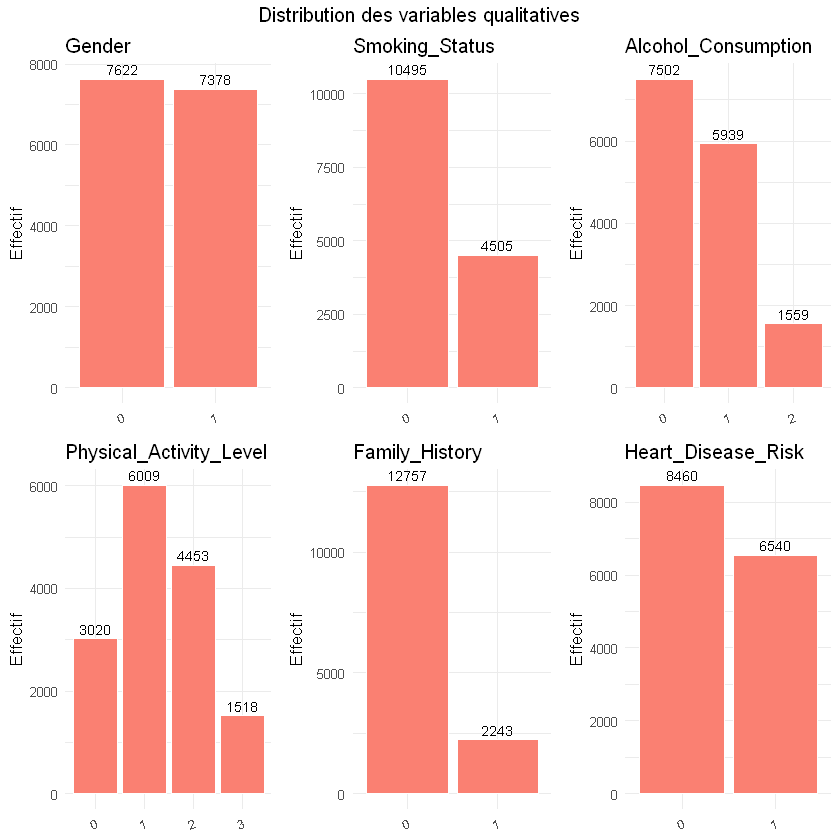

In [10]:

cat_cols <- c("Gender", "Smoking_Status", "Alcohol_Consumption",
              "Physical_Activity_Level", "Family_History", "Heart_Disease_Risk")

plots_qual <- lapply(cat_cols, function(col) {
  ggplot(df, aes_string(x = col)) +
    geom_bar(fill = "salmon", color = "white") +
    geom_text(stat = "count", aes(label = after_stat(count)),
              vjust = -0.4, size = 3) +
    labs(title = col, x = NULL, y = "Effectif") +
    theme_minimal(base_size = 10) +
    theme(axis.text.x = element_text(angle = 20, hjust = 1))
})

grid.arrange(grobs = plots_qual, ncol = 3,
             top = "Distribution des variables qualitatives")

**Distribution des variables qualitatives**

- `Gender` : répartition équilibrée entre les deux modalités.
- `Smoking_Status` : large majorité de non-fumeurs dans la population étudiée.
- `Alcohol_Consumption` : la modalité 0 (aucune consommation) est majoritaire, suivie de la consommation modérée puis élevée.
- `Physical_Activity_Level` : les quatre niveaux d'activité sont relativement bien répartis, avec une légère surreprésentation des niveaux intermédiaires.
- `Family_History` : les antécédents familiaux de maladie cardiaque concernent une minorité de patients.
- `Heart_Disease_Risk` : environ 43.6% des patients présentent un risque élevé, les classes sont suffisamment équilibrées pour éviter tout problème de déséquilibre majeur en modélisation.

#### Statistique bidimensionnelle

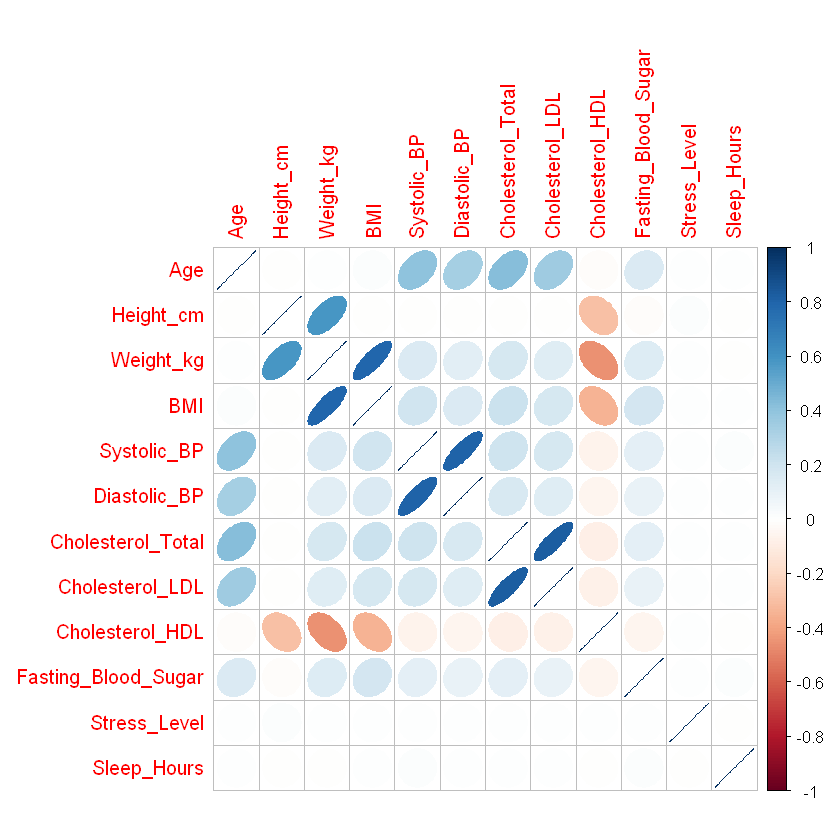

In [11]:
# Regroupement des variables quantitatives dans une matrice 
quant_cols <- c("Age", "Height_cm", "Weight_kg", "BMI",
                "Systolic_BP", "Diastolic_BP", "Cholesterol_Total",
                "Cholesterol_LDL", "Cholesterol_HDL",
                "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours")

# Matrice de corrélation 
corrplot(cor(df[, quant_cols]), method="ellipse")

La corrélation la plus forte et la plus attendue est celle entre `Weight_kg` et `BMI` (corrélation positive très élevée, ellipse très allongée en bleu foncé), ce qui est logique puisque le BMI est directement calculé à partir du poids. On observe également une corrélation positive notable entre `Cholesterol_Total` et `Cholesterol_LDL`, confirmant que le "mauvais" cholestérol constitue la composante principale du cholestérol total, ainsi qu'une corrélation positive entre `Systolic_BP` et `Diastolic_BP`, cohérente médicalement. En revanche, la grande majorité des autres paires de variables présentent des corrélations très faibles voire nulles, ce qui indique une indépendance majoritaire entre les variables.

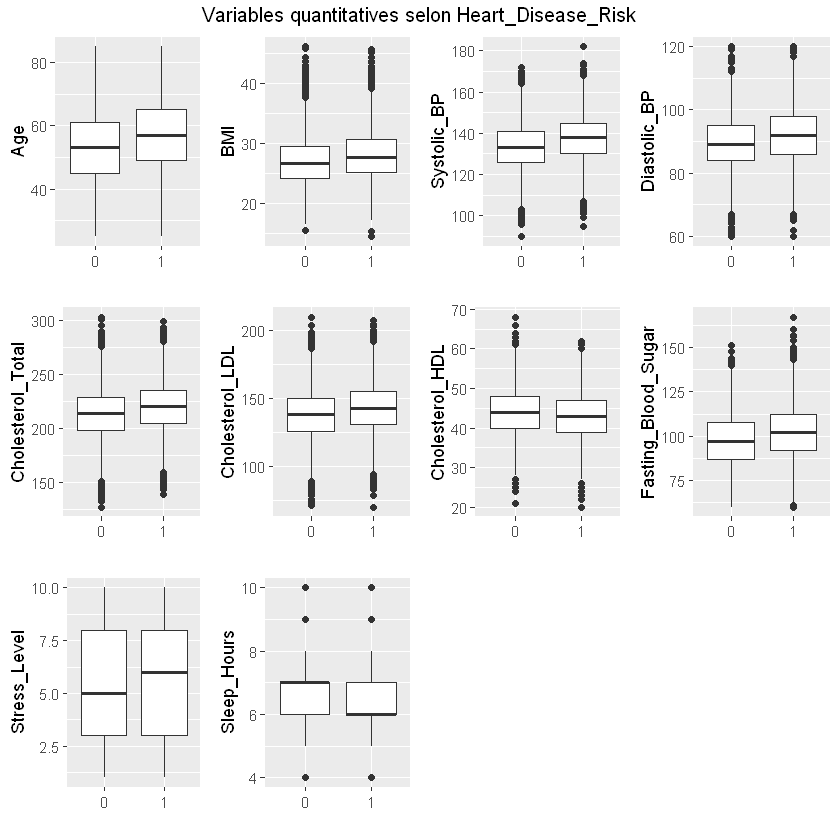

In [12]:
g1  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Age"]))             + geom_boxplot() + xlab("") + ylab("Age")
g2  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "BMI"]))             + geom_boxplot() + xlab("") + ylab("BMI")
g3  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Systolic_BP"]))     + geom_boxplot() + xlab("") + ylab("Systolic_BP")
g4  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Diastolic_BP"]))    + geom_boxplot() + xlab("") + ylab("Diastolic_BP")
g5  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Cholesterol_Total"]))+ geom_boxplot()+ xlab("") + ylab("Cholesterol_Total")
g6  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Cholesterol_LDL"])) + geom_boxplot() + xlab("") + ylab("Cholesterol_LDL")
g7  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Cholesterol_HDL"])) + geom_boxplot() + xlab("") + ylab("Cholesterol_HDL")
g8  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Fasting_Blood_Sugar"]))+ geom_boxplot()+ xlab("") + ylab("Fasting_Blood_Sugar")
g9  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Stress_Level"]))    + geom_boxplot() + xlab("") + ylab("Stress_Level")
g10 <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Sleep_Hours"]))     + geom_boxplot() + xlab("") + ylab("Sleep_Hours")

grid.arrange(g1, g2, g3, g4, g5, g6, g7, g8, g9, g10, ncol = 4,
             top = "Variables quantitatives selon Heart_Disease_Risk")
rm(g1, g2, g3, g4, g5, g6, g7, g8, g9, g10)

`Age` et `Stress_Level` sont les variables qui montrent la différence la plus visible entre les deux groupes, les patients à risque élevé (1) sont en moyenne plus âgés et plus stressés.
`Systolic_BP`, `Cholesterol_LDL` et `Fasting_Blood_Sugar` présentent également une légère tendance à des valeurs plus élevées chez les patients à risque, ce qui est cohérent médicalement. En revanche, `BMI`, `Diastolic_BP`, `Cholesterol_Total`, `Cholesterol_HDL` et `Sleep_Hours` montrent des distributions quasi-identiques entre les deux groupes, suggérant un faible pouvoir discriminant univarié pour ces variables.

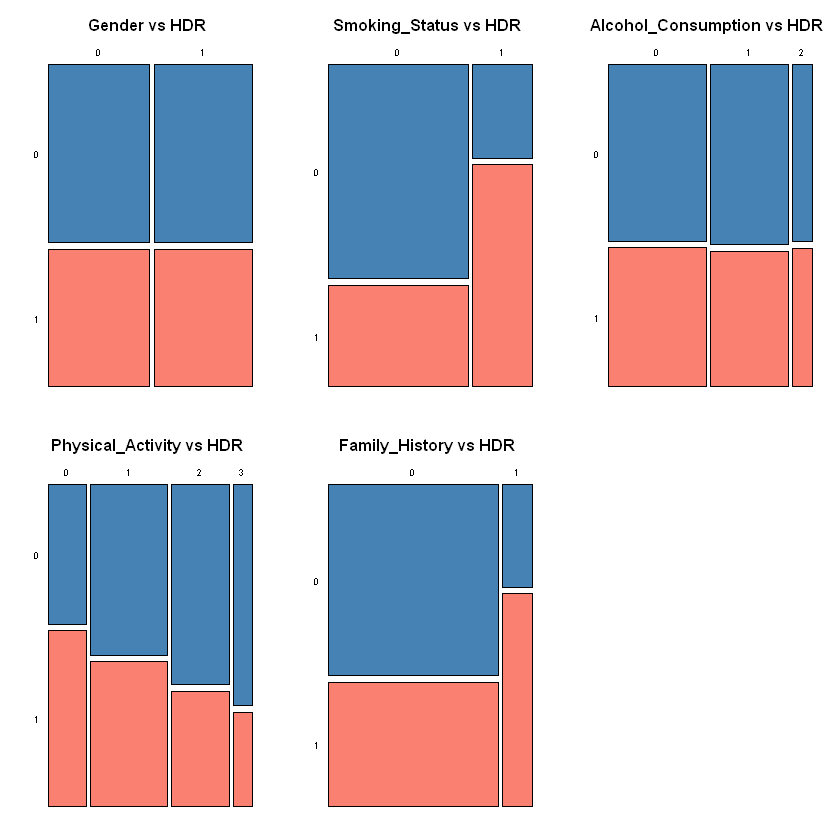

In [13]:
par(mfrow = c(2, 3), mar = c(2, 2, 3, 1))
mosaicplot(table(df[, "Gender"],                 df[, "Heart_Disease_Risk"]),
           main = "Gender vs HDR",                color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Smoking_Status"],          df[, "Heart_Disease_Risk"]),
           main = "Smoking_Status vs HDR",         color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Alcohol_Consumption"],     df[, "Heart_Disease_Risk"]),
           main = "Alcohol_Consumption vs HDR",    color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Physical_Activity_Level"], df[, "Heart_Disease_Risk"]),
           main = "Physical_Activity vs HDR",      color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Family_History"],          df[, "Heart_Disease_Risk"]),
           main = "Family_History vs HDR",         color = c("steelblue", "salmon"), las = 1)
par(mfrow = c(1, 1))

- `Gender` et `Alcohol_Consumption` montrent une proportionnalité au niveau des rectangles, révélant ainsi peu de dépendance avec `Heart_Disease_Risk`.
- `Physical_Activity` montre une tendance descendante : l'augmentation du niveau d'activité physique s'accompagne d'une diminution du risque de maladie cardiaque.
- `Family_History` et `Smoking_Status` révèlent une dépendance claire avec `Heart_Disease_Risk`, les patients ayant des antécédents familiaux ou étant fumeurs sont proportionnellement plus à risque élevé.

### Analyse en composante princilpale

L'objectif de l'ACP est de résumer l'information contenue dans les 12 variables quantitatives explicatives en un nombre réduit de composantes principales, tout en conservant un maximum de variance. 



##### Sélection des variables quantitatives


In [14]:
quant_cols <- c("Age", "Height_cm", "Weight_kg", "BMI",
                "Systolic_BP", "Diastolic_BP",
                "Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL",
                "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours")

df_quant <- df[, quant_cols]

##### Réalisation de l’ACP

Les variables étant exprimées dans des unités différentes, on réalise une ACP réduite (standardisation des variables).

In [15]:
acp <- PCA(df_quant,
           scale.unit = TRUE,
           graph = FALSE)

Ce graphique permet de déterminer combien de composantes principales conserver.




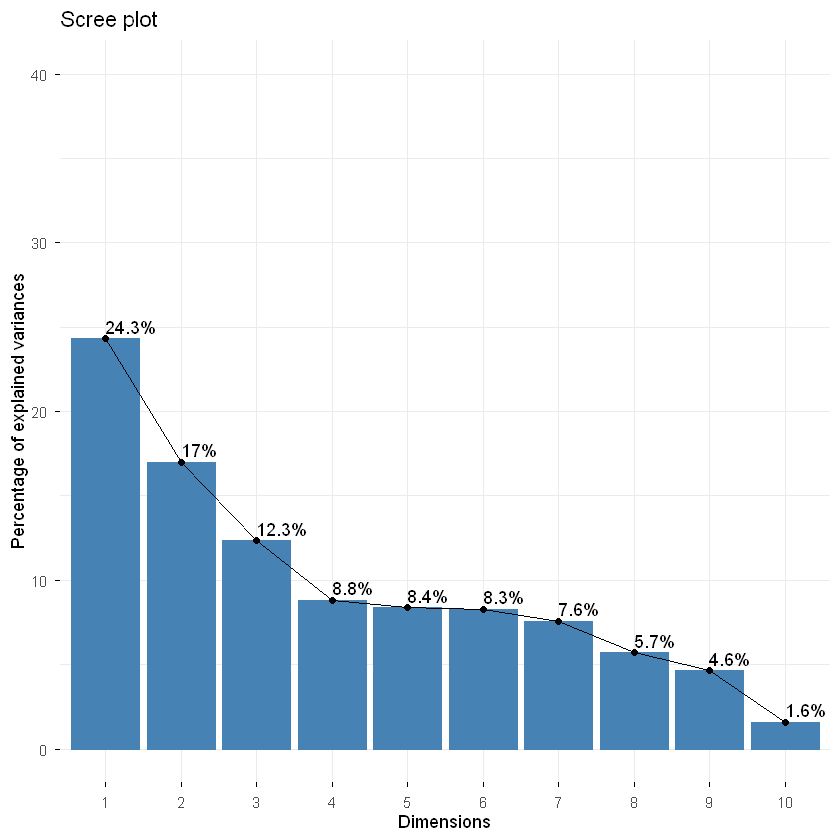

In [16]:
fviz_eig(acp, addlabels = TRUE, ylim = c(0, 40))


La décroissance des valeurs propres montre que :

les premières composantes principales expliquent la majorité de la variance

La première dimension explique 24,3% de la variance, la deuxième 17% et la troisième 12,3%.

À elles trois, elles résument 53,6% de l'information totale.

On observe un coude net après la dimension 3.

Nous retiendrons les 3 premières dimensions pour la suite de l'analyse. 


##### Distribution des individus selon les composantes

On observe ici la dispersion des individus dans l’espace des composantes principales.

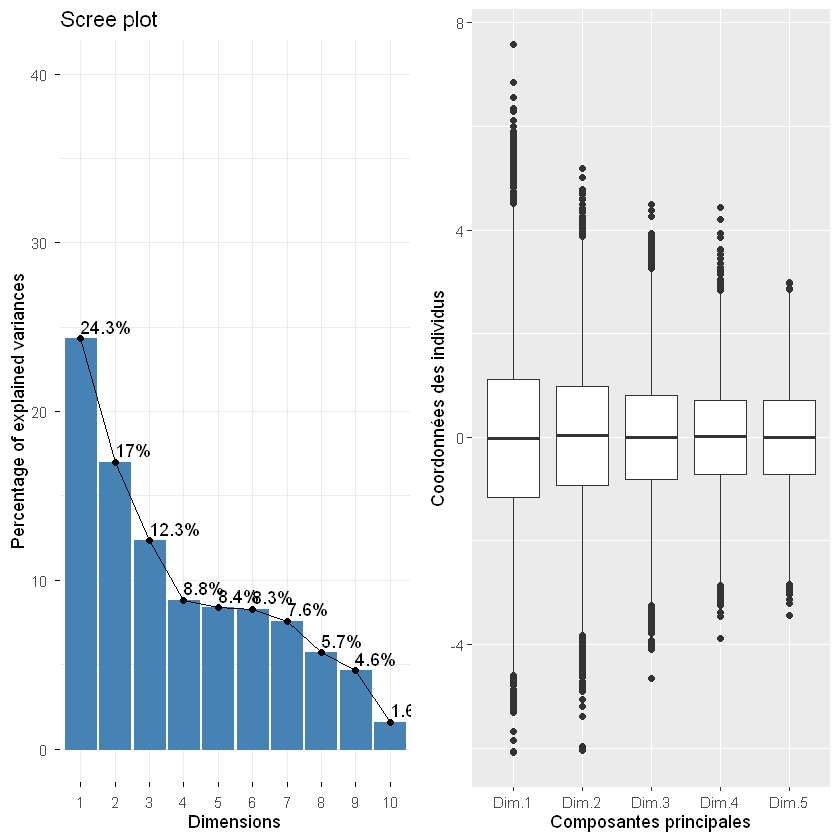

In [18]:
g1 <- fviz_eig(acp, addlabels = TRUE, ylim = c(0,40))

g2 <- ggplot(melt(acp$ind$coord), aes(x = Var2, y = value)) +
  geom_boxplot() +
  xlab("Composantes principales") +
  ylab("Coordonnées des individus")

grid.arrange(g1, g2, ncol = 2)

Ce graphique permet de visualiser :

la dispersion des individus selon chaque composante

La dispersion des individus (boxplot) semble homogène, sans valeurs atypiques extrêmes écrasant les axes, ce qui suggère l’absence de valeurs aberrantes majeures dans les données.

##### Structure de corrélation des variables


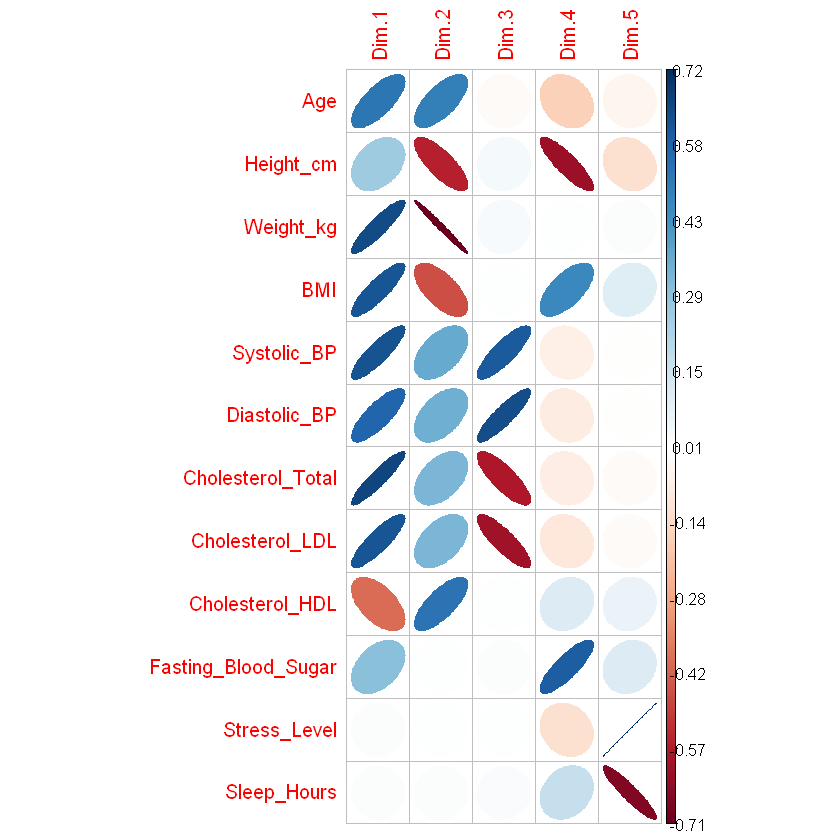

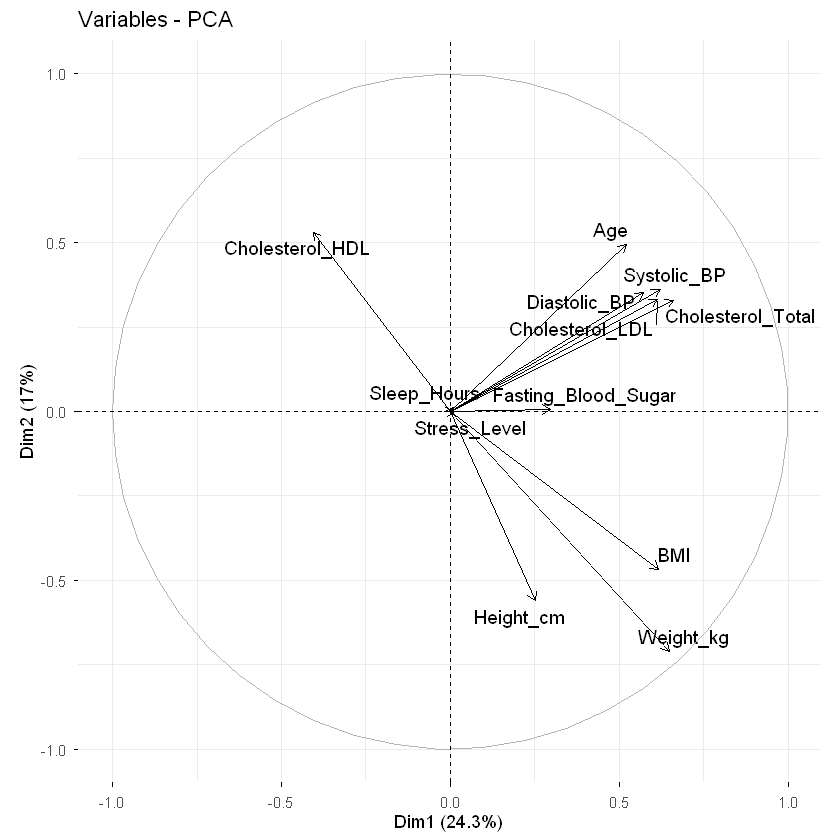

In [19]:
# Matrice de corrélation entre variables et composantes principales
corrplot(acp$var$cor, is.corr = FALSE, method = "ellipse")

# Cercle des corrélations (Dimensions 1 et 2)
fviz_pca_var(acp, axes = c(1, 2), repel = TRUE)

Ce graphique représente les corrélations entre les variables initiales et les composantes principales. La proximité des variables par rapport au cercle extérieur indique qu'elles sont bien représentées par ce premier plan factoriel.

L'Axe 1 (24.3%) : Il définit un axe de "Morphologie et Lipides". On y observe une forte corrélation positive entre le poids (Weight_kg), l'IMC (BMI), le Cholesterol_Total et le Cholesterol_LDL. Médicalement, cela confirme que le "mauvais cholestérol" (LDL) est la composante majeure du cholestérol total dans cet échantillon.

Opposition : Le Cholesterol_HDL (bon cholestérol) est situé à l'opposé du LDL sur cet axe, ce qui est médicalement intuitif : un profil lipidique dégradé associe souvent un LDL haut et un HDL bas.

L'Axe 2 (17%) : Il est principalement porté par l'Âge et la Taille (Height_cm). On note que l'âge est presque orthogonal (à 90°) au poids et au BMI, suggérant que dans ce jeu de données synthétiques, la prise de poids ne dépend pas uniquement du vieillissement.

##### Projection des individus et Risque Cardiaque

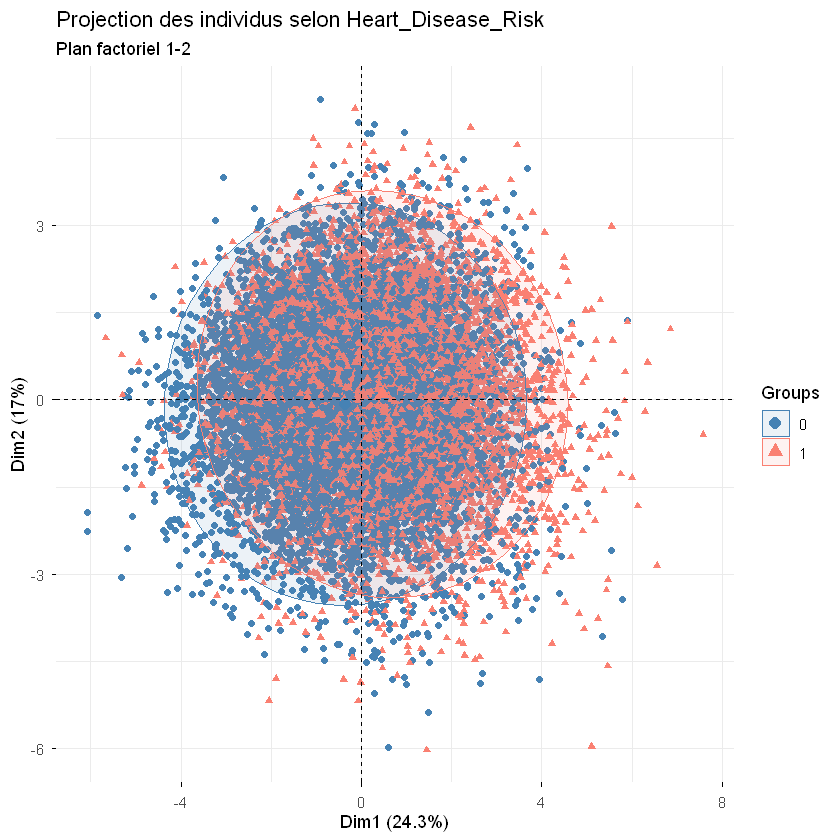

In [20]:
# Projection des individus avec coloration par Heart_Disease_Risk (habillage)
fviz_pca_ind(acp, 
             habillage = df$Heart_Disease_Risk, 
             label = "none", 
             addEllipses = TRUE, 
             palette = c("steelblue", "salmon")) +
  labs(title = "Projection des individus selon Heart_Disease_Risk",
       subtitle = "Plan factoriel 1-2")

Chaque point représente un patient projeté dans l'espace réduit des deux premières composantes. L'objectif est de visualiser si les variables explicatives permettent de séparer naturellement les patients à risque (1) des patients à faible risque (0).

On remarque une absence de clusters distincts. Les deux nuages de points se chevauchent presque intégralement, et leurs ellipses de confiance sont centrées.

Question : Une discrimination linéaire est-elle possible ?
Non, une discrimination linéaire simple par un hyperplan semble impossible à ce stade sur les variables quantitatives seules. Les données présentent une structure continue.

Cela montre que le risque cardiaque est un phénomène multidimensionnel complexe. Une simple règle basée sur le poids ou le cholestérol ne suffit pas à séparer les classes, ce qui justifie le recours ultérieur à des modèles de classification supervisée (Machine Learning) pour prédire Heart_Disease_Risk.

##### Projection selon d'autres axes (Dimensions 1 et 3)

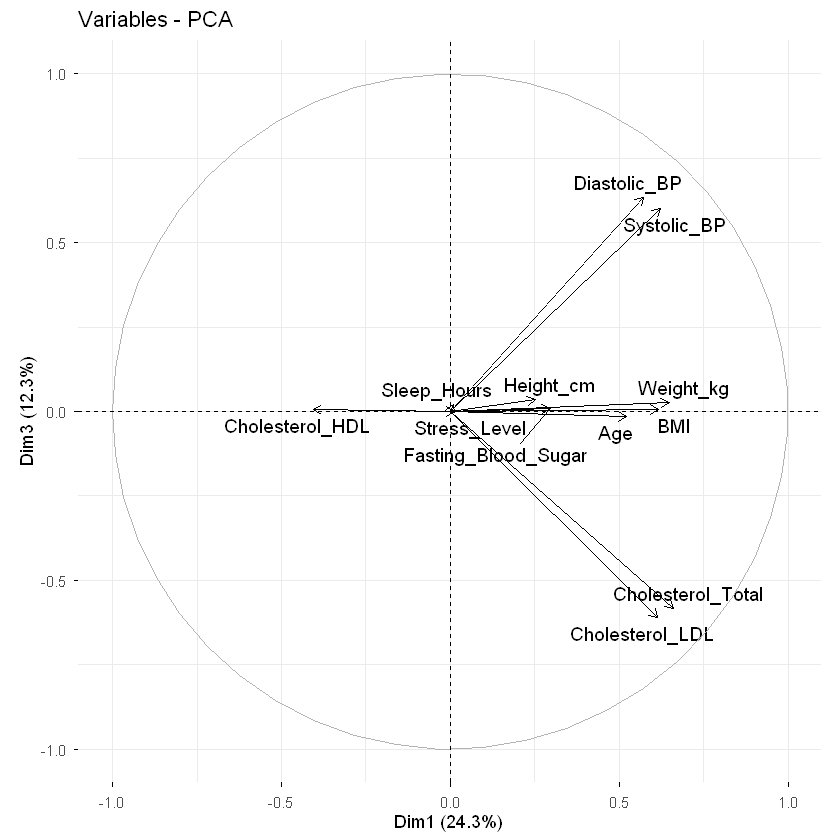

In [21]:
# Cercle des corrélations (Dimensions 1 et 3)
fviz_pca_var(acp, axes = c(1, 3), repel = TRUE)

La projection sur les axes 1 et 3 permet d'identifier des structures de corrélation qui n'étaient pas visibles sur le premier plan factoriel.On constate que les variables de Tension Artérielle (Systolic_BP et Diastolic_BP) sont très fortement corrélées à l'axe 3 ($12.3\%$).Ces variables sont quasi-orthogonales (à $90^\circ$) aux variables de poids et de cholestérol de l'axe 1. Cela signifie que, dans ce jeu de données, l'hypertension artérielle constitue un facteur de risque indépendant de la corpulence ou des lipides. Cette structure est cohérente avec les réalités médicales.

##### Visualisation selon la variable à prédire (Heart_Disease_Risk)

On colore les individus selon Heart_Disease_Risk.



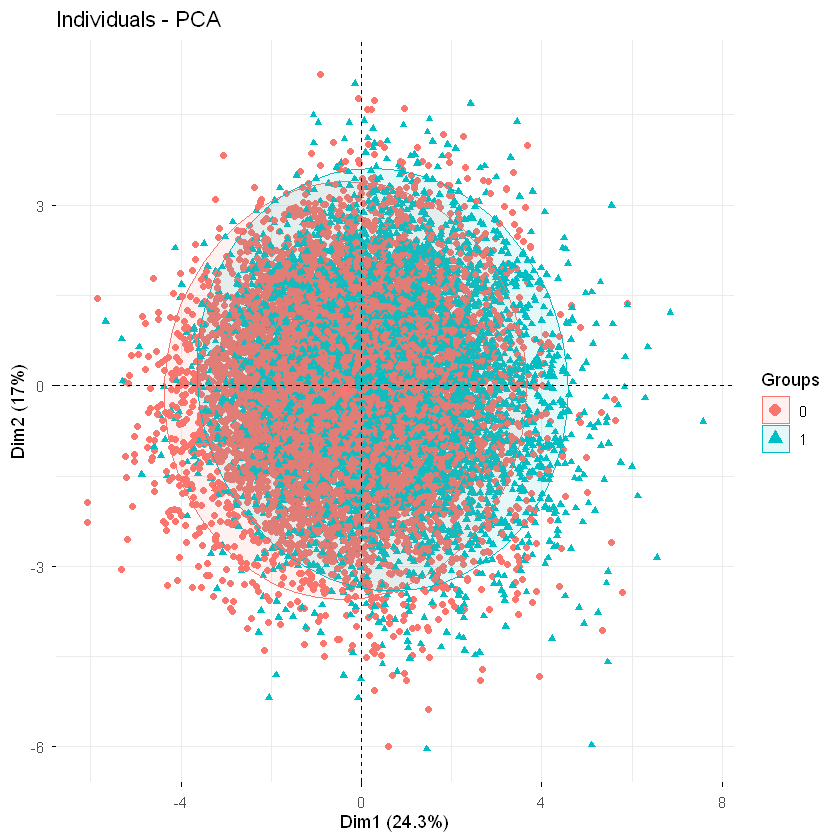

In [22]:
fviz_pca_ind(acp,
             label = "none",
             habillage = df$Heart_Disease_Risk,
             addEllipses = TRUE)    

Cette représentation permet d'évaluer si les deux classes (Risque faible et Risque élevé) sont séparables dans l'espace des composantes principales.

Observation : On constate un chevauchement quasi-total des deux groupes. Les ellipses de confiance sont centrées sur les mêmes zones du plan factoriel.

Conclusion : La séparation entre les classes n'est pas linéairement possible sur les premières composantes. Cela suggère que le risque cardiaque ne dépend pas d'un seul facteur majeur, mais d'une combinaison complexe de variables.

Suite du projet : Ce constat justifie l'utilisation de méthodes de classification plus puissantes (comme la Régression Logistique ou les Forêts Aléatoires) qui seront explorées dans la suite de l'étude.